In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

data_path = "/content/malaria-detection-dataset/Dataset"

for dirname, _, filenames in os.walk(data_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163029_cell_1.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163029_cell_202.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163047_cell_26.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163029_cell_44.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163002_cell_97.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_162922_cell_211.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163002_cell_146.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163029_cell_57.png
/content/malaria-detection-dataset/Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163047_cell_161.png
/content/malaria-detection-dataset

In [ ]:
import keras
from keras.applications.vgg19 import VGG19

In [ ]:
image_size = [224,224]
WIDTH = 151
HEIGHT = 136
BATCH_SIZE = 32
train_path = '../input/malaria-detection-dataset/Dataset/Train'
test_path = '../input/malaria-detection-dataset/Dataset/Test'

In [ ]:
vgg19 = VGG19(input_shape=image_size+[3],weights="imagenet",include_top=False)

for layers in vgg19.layers:
    layers.trainable=False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from keras.layers import Dense, Flatten
from keras.models import Sequential, Model
x = Flatten()(vgg19.output)
prediction = Dense(2, activation='softmax')(x)
model = Model(inputs=vgg19.input, outputs=prediction)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,074,562 (76.58 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [ ]:
import tensorflow as tf
train_path = "/content/malaria-detection-dataset/Dataset/Train"
test_path = "/content/malaria-detection-dataset/Dataset/Test"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.


In [ ]:
import tensorflow as tf
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
            directory=train_path,
            shuffle=True,
            image_size=(WIDTH,HEIGHT),
            batch_size = BATCH_SIZE,
)

Found 416 files belonging to 2 classes.


In [ ]:
import shutil

# Remove the hidden checkpoints folder
shutil.rmtree('/content/malaria-detection-dataset/Dataset/Train/.ipynb_checkpoints', ignore_errors=True)
shutil.rmtree('/content/malaria-detection-dataset/Dataset/Test/.ipynb_checkpoints', ignore_errors=True)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/malaria-detection-dataset/Dataset/Train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/malaria-detection-dataset/Dataset/Test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


Found 416 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


In [ ]:
test_set = test_datagen.flow_from_directory('../content/malaria-detection-dataset/Dataset/Test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 134 images belonging to 2 classes.


In [ ]:
print(training_set.class_indices)


{'Parasite': 0, 'Uninfected': 1}


In [ ]:
#Remove afterwards
import os

train_dir = '/content/malaria-detection-dataset/Dataset/Train'

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))


Uninfected : 196
Parasite : 220


In [ ]:
#r = model.fit(
 #   training_set,
  #  validation_data=test_set,
   # epochs=50
#)

import tensorflow as tf

WIDTH, HEIGHT = 224, 224
BATCH_SIZE = 32

train_dir = '/content/malaria-detection-dataset/Dataset/Train'
test_dir  = '/content/malaria-detection-dataset/Dataset/Test'

# ✅ Load datasets using the modern API
training_set = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='binary',     # binary classification
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_set = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ✅ Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
training_set = training_set.map(lambda x, y: (normalization_layer(x), y))
test_set = test_set.map(lambda x, y: (normalization_layer(x), y))

# ✅ Define model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ Train
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=50
)




Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.5457 - loss: 1.5247 - val_accuracy: 0.6119 - val_loss: 0.6797
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.6827 - loss: 0.5792 - val_accuracy: 0.5970 - val_loss: 0.6868
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.7188 - loss: 0.5378 - val_accuracy: 0.6269 - val_loss: 0.6961
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7885 - loss: 0.4424 - val_accuracy: 0.5000 - val_loss: 0.7989
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9183 - loss: 0.2476 - val_accuracy: 0.5746 - val_loss: 0.7958
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9495 - loss: 0.1593 - val_accuracy: 0.4552 - val_loss: 1.2631
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.9784 - loss: 0.0868 - val_accuracy: 0.5821 - val_loss: 1.0192
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.9688 - loss: 0.0910 - val_accuracy: 0.5672 - val_loss:

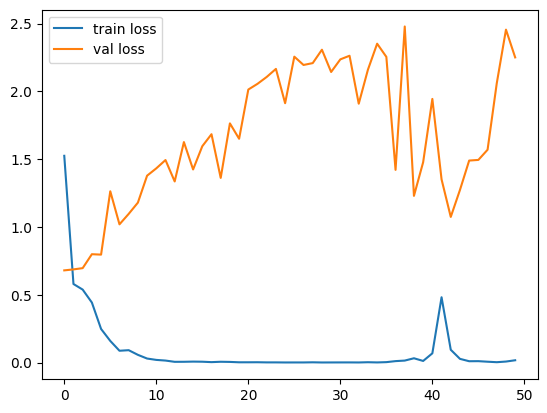

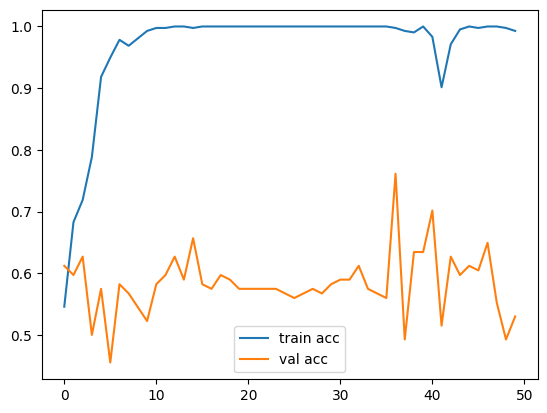

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
model.save('malaria_model.h5')

In [ ]:
model.save('malaria_model.keras')

Plotting Some Images:

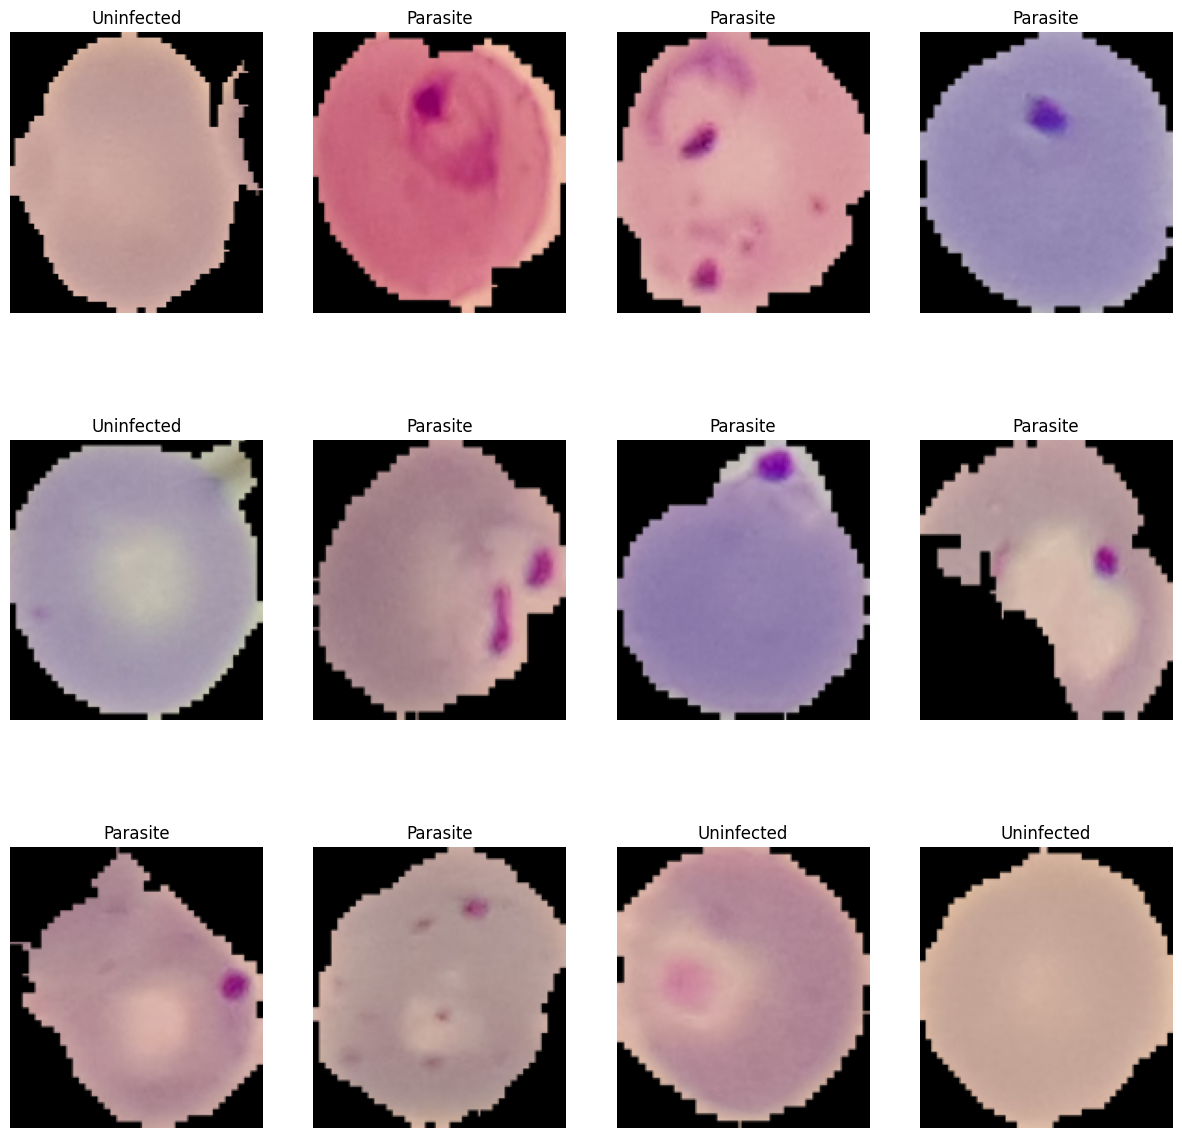

In [ ]:
classnames = train_dataset.class_names
classnames
plt.figure(figsize = (15,15))
for image, label in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(classnames[label[i]])
        plt.axis('off')


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

WIDTH, HEIGHT = 224, 224
BATCH_SIZE = 32

test_dir  = '/content/malaria-detection-dataset/Dataset/Test'

test_ds = image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


Found 134 files belonging to 2 classes.


**EVALUATION OF THE PERFORMANCE METRICS**

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 555ms/step


<Figure size 600x600 with 0 Axes>

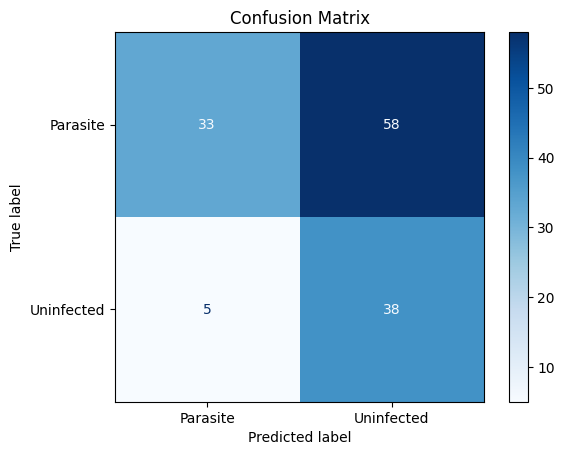

==== Performance Metrics ====
Accuracy : 0.5299
Precision: 0.3958
Recall   : 0.8837
F1 Score : 0.5468
AUC      : 0.7953

Classification Report:
              precision    recall  f1-score   support

    Parasite       0.87      0.36      0.51        91
  Uninfected       0.40      0.88      0.55        43

    accuracy                           0.53       134
   macro avg       0.63      0.62      0.53       134
weighted avg       0.72      0.53      0.52       134



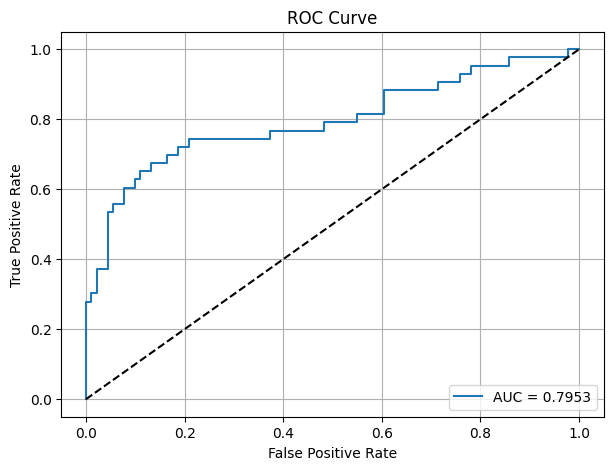

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# 1️⃣ Collect true labels and predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = model.predict(test_ds).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

# 2️⃣ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Parasite', 'Uninfected']
)

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 3️⃣ Classification Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred_probs)

print("==== Performance Metrics ====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Parasite', 'Uninfected']
    )
)

# 4️⃣ ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
# Extract base model from the existing trained model
base_model = model.layers[0]  # first layer is EfficientNetB0
print(f"Base model: {base_model.name}")


Base model: conv2d


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks

# 1️⃣ Unfreeze all layers in the main model container
model.trainable = True

# Freeze all layers except the last 50
for layer in model.layers[:-50]:
    layer.trainable = False

# 2️⃣ Recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3️⃣ Setup callbacks (early stopping + best model checkpoint)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    'best_finetuned_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# 4️⃣ Fine-tune the model
history_finetune = model.fit(
    training_set,
    validation_data=test_set,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9952 - auc: 1.0000 - loss: 0.0109 - val_accuracy: 0.5448 - val_auc: 0.7465 - val_loss: 2.1791
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0047 - val_accuracy: 0.5448 - val_auc: 0.7520 - val_loss: 2.1222
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0044 - val_accuracy: 0.5448 - val_auc: 0.7608 - val_loss: 2.0696
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0031 - val_accuracy: 0.5373 - val_auc: 0.7617 - val_loss: 2.0332
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 62s 5s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0033 - val_accuracy: 0.5672 - val_auc: 0.7663 - val_loss: 1.9937
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0025 - val_accuracy: 0.5746 - val_auc: 0.7667 - val_loss: 1.9715
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 111s 6s/step -

**CLEAN CODE FOR CNN MODEL**

Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.5841 - loss: 1.0089 - val_accuracy: 0.6791 - val_loss: 0.6674
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7308 - loss: 0.5544 - val_accuracy: 0.4627 - val_loss: 0.7882
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.7909 - loss: 0.4496 - val_accuracy: 0.6567 - val_loss: 0.6880
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8486 - loss: 0.3616 - val_accuracy: 0.7313 - val_loss: 0.5659
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8918 - loss: 0.2503 - val_accuracy: 0.6493 - val_loss: 0.6691
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9615 - loss: 0.1377 - val_accuracy: 0.4776 - val_loss: 1.1020
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9639 - loss: 0.1106 - val_accuracy: 0.5672 - val_loss: 0.9030
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9808 - loss: 0.0743 - val_accuracy: 0.5075 - val_loss:

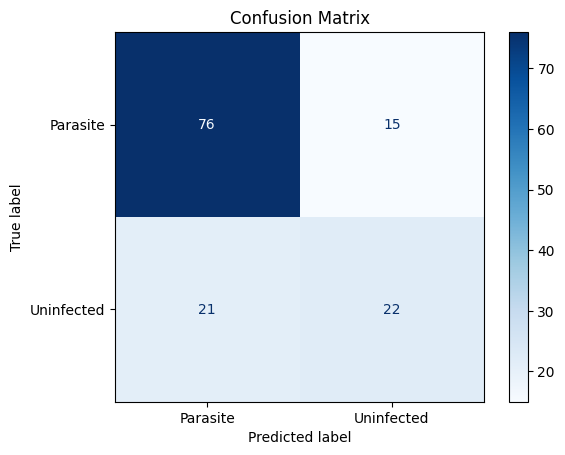

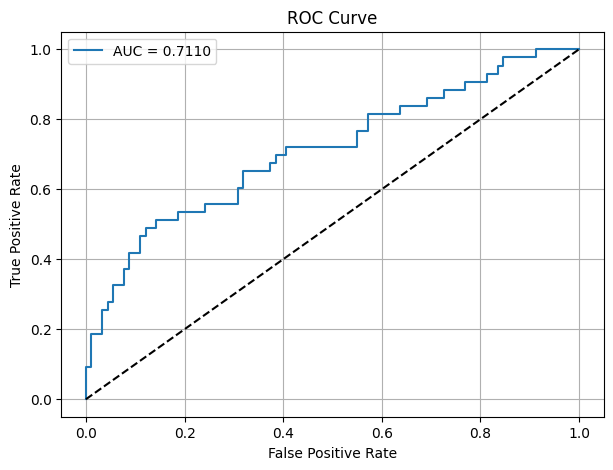

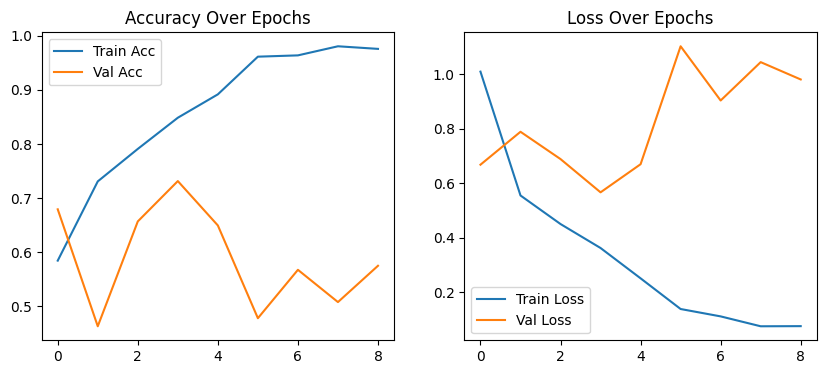

In [ ]:
# ================================
# 1️⃣ Setup & Imports
# ================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

# Paths
train_dir = '/content/malaria-detection-dataset/Dataset/Train'
test_dir  = '/content/malaria-detection-dataset/Dataset/Test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ================================
# 2️⃣ Load & Preprocess Dataset
# ================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False
)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)

# ================================
# 3️⃣ Build CNN Model
# ================================
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ================================
# 4️⃣ Train Model
# ================================
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[early_stopping]
)

# ================================
# 5️⃣ Evaluate Model
# ================================
# Collect true labels and predictions
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred_probs)

print("==== Performance Metrics ====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Parasite','Uninfected']))

# ================================
# 6️⃣ Visualize Results
# ================================
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Parasite','Uninfected'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Learning Curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.show()


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

# 1️⃣ Build Transfer Learning Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base model for initial training

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 2️⃣ Train
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,  # start small
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# 3️⃣ Fine-tune (unfreeze top layers)
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),  # very small LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.5793 - loss: 0.6969 - val_accuracy: 0.3209 - val_loss: 0.7296
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5072 - loss: 0.7210 - val_accuracy: 0.3209 - val_loss: 0.7603
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5216 - loss: 0.7034 - val_accuracy: 0.6791 - val_loss: 0.6572
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5144 - loss: 0.6954 - val_accuracy: 0.6791 - val_loss: 0.6520
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5481 - loss: 0.6967 - val_accuracy: 0.3209 - val_loss: 0.6971
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4856 - loss: 0.7146 - val_accuracy: 0.6791 - val_loss: 0.6630
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4904 - loss: 0.7044 - val_accuracy: 0.3209 - val_loss: 0.7070
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.471

**EfficientNETBO**

Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.4688 - loss: 3.3621 - val_accuracy: 0.4403 - val_loss: 0.6936
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5986 - loss: 0.6840 - val_accuracy: 0.7239 - val_loss: 0.6778
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6827 - loss: 0.6308 - val_accuracy: 0.6269 - val_loss: 0.6447
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7692 - loss: 0.5344 - val_accuracy: 0.6194 - val_loss: 0.6410
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.8293 - loss: 0.3976 - val_accuracy: 0.5896 - val_loss: 0.7008
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.8822 - loss: 0.2923 - val_accuracy: 0.6343 - val_loss: 0.6371
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9303 - loss: 0.2077 - val_accuracy: 0.5597 - val_loss: 0.8425
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9567 - loss: 0.1515 - val_accuracy: 0.6045 - val_loss:

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 585ms/step
==== Performance Metrics ====
Accuracy : 0.6343
Precision: 0.4571
Recall   : 0.7442
F1 Score : 0.5664
AUC      : 0.7577

Classification Report:
              precision    recall  f1-score   support

    Parasite       0.83      0.58      0.68        91
  Uninfected       0.46      0.74      0.57        43

    accuracy                           0.63       134
   macro avg       0.64      0.66      0.63       134
weighted avg       0.71      0.63      0.65       134



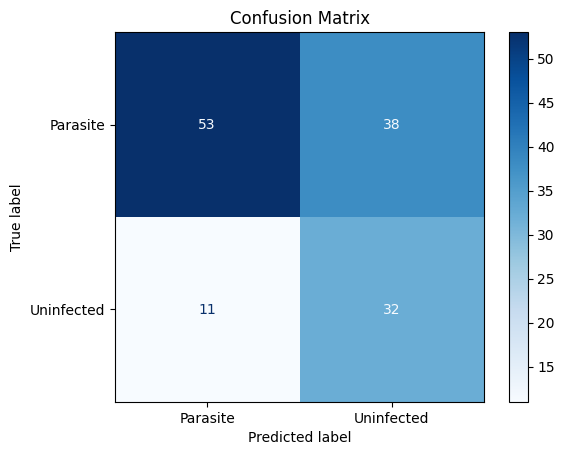

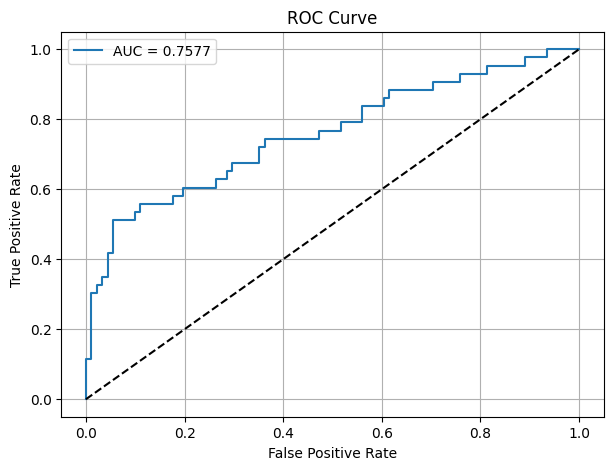

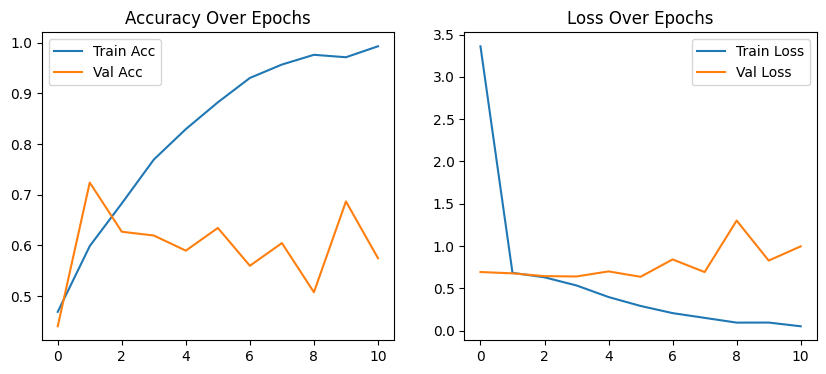

In [ ]:
# ================================
# 1️⃣ Setup & Imports
# ================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

# Paths
train_dir = '/content/malaria-detection-dataset/Dataset/Train'
test_dir  = '/content/malaria-detection-dataset/Dataset/Test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ================================
# 2️⃣ Load & Preprocess Dataset
# ================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False
)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)

# ================================
# 3️⃣ Build CNN Model
# ================================
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ================================
# 4️⃣ Train Model
# ================================
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[early_stopping]
)

# ================================
# 5️⃣ Evaluate Model
# ================================
# Collect true labels and predictions
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred_probs)

print("==== Performance Metrics ====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Parasite','Uninfected']))

# ================================
# 6️⃣ Visualize Results
# ================================
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Parasite','Uninfected'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Learning Curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
import numpy as np

# ✅ 1️⃣ Build Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ✅ 2️⃣ Load EfficientNetB0 Base
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)
base_model.trainable = False  # Freeze for warm-up training

# ✅ 3️⃣ Build the Model
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ 4️⃣ Compute Class Weights (Flattened to 1D array to avoid TypeError)
y_train_labels = np.concatenate([y.numpy().ravel() for _, y in train_ds], axis=0)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# ✅ 5️⃣ Warm-up Training
history_warmup = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    class_weight=class_weights_dict
)

# ✅ 6️⃣ Fine-Tuning (Unfreeze Last 30 Layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Smaller LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weights_dict
)

Class Weights: {0: np.float64(0.9454545454545454), 1: np.float64(1.0612244897959184)}
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.5120 - loss: 0.6979 - val_accuracy: 0.3209 - val_loss: 0.7065
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.4543 - loss: 0.7047 - val_accuracy: 0.3209 - val_loss: 0.6968
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.5361 - loss: 0.6921 - val_accuracy: 0.3209 - val_loss: 0.6947
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4832 - loss: 0.7001 - val_accuracy: 0.3209 - val_loss: 0.6937
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.5024 - loss: 0.6954 - val_accuracy: 0.3209 - val_loss: 0.6943
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.4808 - loss: 0.7007 - val_accuracy: 0.3209 - val_loss: 0.6953
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.4591 - loss: 0.7053 - val_accuracy: 0.3209 - val_loss: 0.6943
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━

Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.
Class Weights: {0: np.float64(0.9454545454545454), 1: np.float64(1.0612244897959184)}


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 1,498,722 (5.72 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.7500 - loss: 0.5282 - val_accuracy: 0.9478 - val_loss: 0.3024
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.9279 - loss: 0.2573 - val_accuracy: 0.9627 - val_loss: 0.1948
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.9471 - loss: 0.1680 - val_accuracy: 0.9552 - val_loss: 0.1418
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.9591 - loss: 0.1283 - val_accuracy: 0.9552 - val_loss: 0.1133
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.9639 - loss: 0.1134 - val_accuracy: 0.9701 - val_loss: 0.0974
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.9663 - loss: 0.0952 - val_accuracy: 0.9776 - val_loss: 0.0849
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.9736 - loss: 0.0744 - val_accuracy: 0.9776 - val_loss: 0.0773
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.9856 - loss: 0.0595 - val_accuracy: 0.9851 - val_loss:

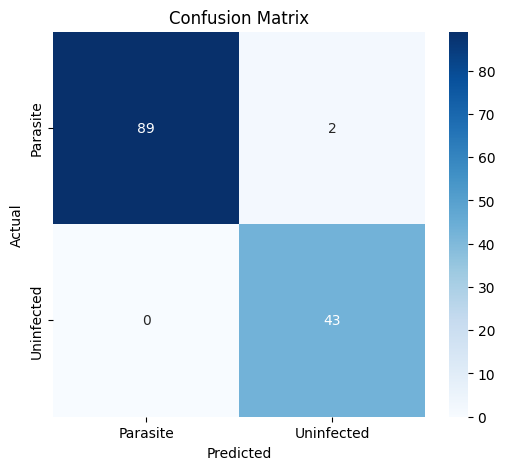

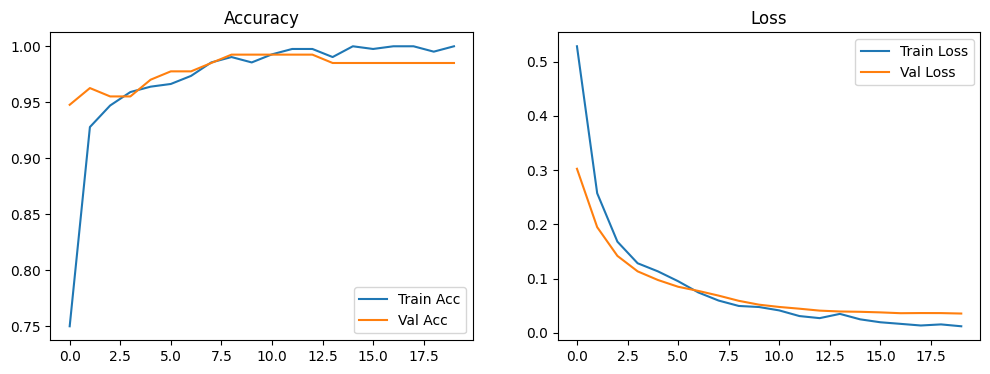

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# =======================
# 1️⃣ Dataset Preparation
# =======================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/malaria-detection-dataset/Dataset/Train"
test_dir  = "/content/malaria-detection-dataset/Dataset/Test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# ✅ Save class names before mapping transforms
class_names = train_ds.class_names

# ✅ Use EfficientNet's official preprocessing instead of Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y))

# Optimize data pipeline caching
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# =======================
# 2️⃣ Compute Class Weights
# =======================
y_train_labels = np.concatenate([y for _, y in train_ds], axis=0)

if y_train_labels.ndim > 1 and y_train_labels.shape[1] > 1:
    y_train_labels = np.argmax(y_train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# =======================
# 3️⃣ Build EfficientNetB0 Model
# =======================
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet"
)

# ✅ Unfreeze top 30 layers to allow feature adaptation
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =======================
# 4️⃣ Train the Model
# =======================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    class_weight=class_weights_dict
)

# =======================
# 5️⃣ Evaluate Performance
# =======================
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

accuracy = np.mean(y_true == y_pred)
precision = tf.keras.metrics.Precision()(y_true, y_pred).numpy()
recall = tf.keras.metrics.Recall()(y_true, y_pred).numpy()
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
auc = roc_auc_score(y_true, y_pred_probs[:, 1])

print("\n==== Performance Metrics ====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_score:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
# ✅ Fix: Pass saved `class_names` list
print(classification_report(y_true, y_pred, target_names=class_names))

# =======================
# 6️⃣ Confusion Matrix
# =======================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =======================
# 7️⃣ Training Curves
# =======================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss")
plt.show()

Improved Ensemble Model

Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.
Classes: ['Parasite', 'Uninfected']
Class Weights: {0: np.float64(0.9454545454545454), 1: np.float64(1.0612244897959184)}


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


🔹 Stage 1: Training classifier head
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.5649 - loss: 0.7186 - val_accuracy: 0.6791 - val_loss: 0.6761
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.5529 - loss: 0.7256 - val_accuracy: 0.6791 - val_loss: 0.6784
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.5529 - loss: 0.7202 - val_accuracy: 0.3209 - val_loss: 0.7027
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.4543 - loss: 0.7813 - val_accuracy: 0.6791 - val_loss: 0.6781
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4856 - loss: 0.7542 - val_accuracy: 0.6791 - val_loss: 0.6557
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5264 - loss: 0.7388 - val_accuracy: 0.6791 - val_loss: 0.6722
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5096 - loss: 0.7188 - val_accuracy: 0.6791 - val_loss: 0.6739
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4784 - loss: 0.75

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


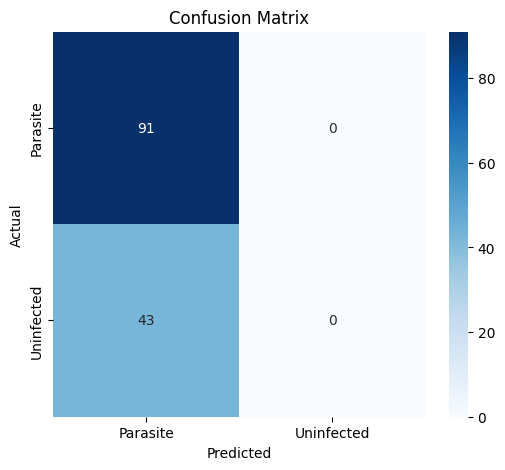

In [ ]:
# =======================
# IMPORTS
# =======================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

AUTOTUNE = tf.data.AUTOTUNE

# =======================
# CONFIGURATION
# =======================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 15
EPOCHS_STAGE2 = 20

train_dir = "/content/malaria-detection-dataset/Dataset/Train"
test_dir  = "/content/malaria-detection-dataset/Dataset/Test"

# =======================
# DATA LOADING (BINARY)
# =======================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =======================
# DATA AUGMENTATION
# =======================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
])

normalization = tf.keras.layers.Rescaling(1./255)

def preprocess(x, y, training=False):
    x = normalization(x)
    if training:
        x = data_augmentation(x)
    return x, y

train_ds = train_ds.map(lambda x, y: preprocess(x, y, True), num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: preprocess(x, y, False), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# =======================
# CLASS WEIGHTS
# =======================
y_train = np.concatenate([y.numpy().ravel() for _, y in train_ds])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weights)

# =======================
# MODEL DEFINITION
# =======================
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

model.summary()

# =======================
# TRAINING – STAGE 1
# =======================
print("\n🔹 Stage 1: Training classifier head")
history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights
)

# =======================
# FINE-TUNING – STAGE 2
# =======================
print("\n🔹 Stage 2: Fine-tuning top EfficientNet layers")

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights
)

# =======================
# EVALUATION
# =======================
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_probs = model.predict(test_ds).ravel()
y_pred = (y_probs >= 0.5).astype(int)

print("\n==== PERFORMANCE METRICS ====")
print("AUC :", roc_auc_score(y_true, y_probs))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Final Emsembled Optimized Model

Found 416 files belonging to 2 classes.
Found 134 files belonging to 2 classes.
Classes: ['Parasite', 'Uninfected']
Class Weights: {0: np.float64(0.7563636363636363), 1: np.float64(1.0612244897959184)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.5962 - auc: 0.6384 - loss: 0.7500 - precision: 0.6029 - recall: 0.4184 - val_accuracy: 0.7836 - val_auc: 0.9192 - val_loss: 0.6166 - val_precision: 0.6029 - val_recall: 0.9535 - learning_rate: 1.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8317 - auc: 0.8903 - loss: 0.3857 - precision: 0.8214 - recall: 0.8214 - val_accuracy: 0.9030 - val_auc: 0.9854 - val_loss: 0.4996 - val_precision: 0.7778 - val_recall: 0.9767 - learning_rate: 1.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8558 - auc: 0.9290 - loss: 0.3015 - precision: 0.8469 - recall: 0.8469 - val_accuracy: 0.9254 - val_auc: 0.9908 - val_loss: 0.4359 - val_precision: 0.8235 - val_recall: 0.9767 - learning_rate: 1.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8846 - auc: 0.9640 - loss: 0.2168 - precision: 0.8524 - recall: 0.9133 - val_accuracy: 0.9030 - val_auc: 0.9935 - val_loss: 0.3984 -

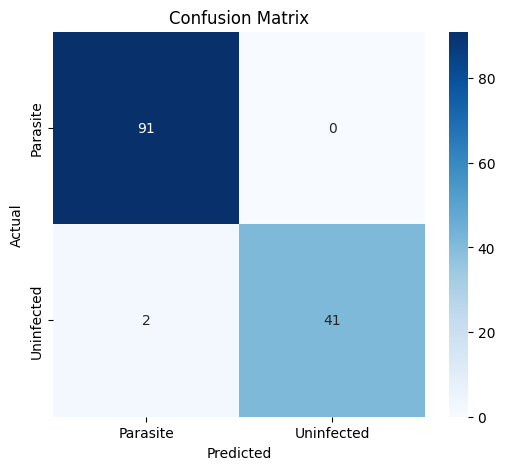

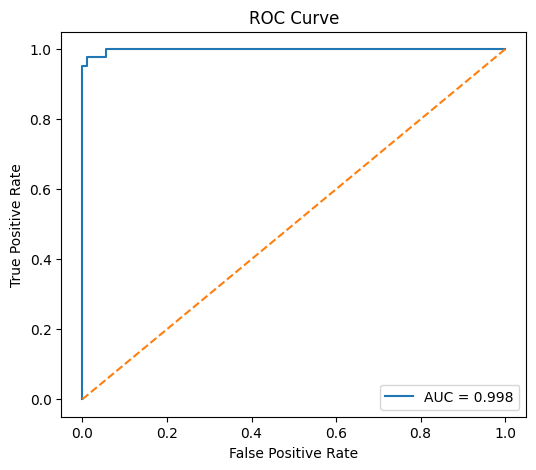

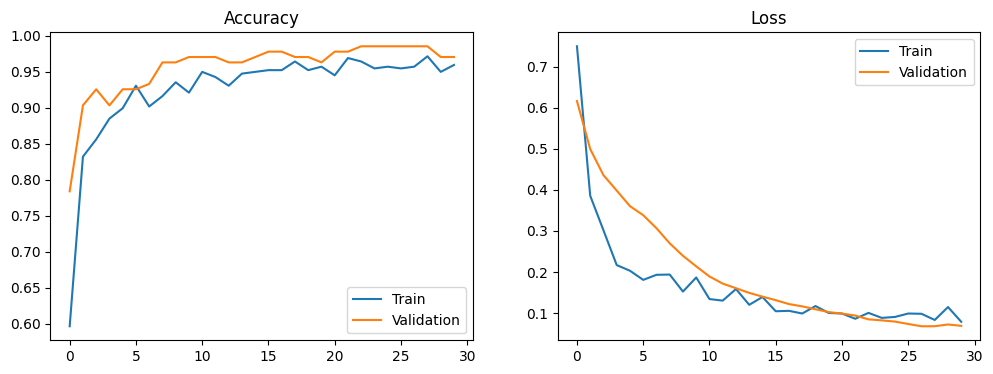

In [ ]:
# =========================================================
# MALARIA PARASITE DETECTION USING ENSEMBLED (OPTIMIZED)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import seaborn as sns

# =========================================================
# 1️⃣ CONFIGURATION
# =========================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30

train_dir = "/content/malaria-detection-dataset/Dataset/Train"
test_dir  = "/content/malaria-detection-dataset/Dataset/Test"

tf.random.set_seed(42)
np.random.seed(42)

# =========================================================
# 2️⃣ LOAD DATASETS (BINARY MODE)
# =========================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =========================================================
# 3️⃣ DATA AUGMENTATION & PREPROCESSING
# =========================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
])

preprocess = tf.keras.applications.efficientnet.preprocess_input

train_ds = train_ds.map(lambda x, y: (data_augmentation(preprocess(x), training=True), y))
test_ds  = test_ds.map(lambda x, y: (preprocess(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

# =========================================================
# 4️⃣ CLASS WEIGHTS (SAFE BALANCING)
# =========================================================
y_train = np.concatenate([y.numpy().ravel() for _, y in train_ds])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

# Reduce aggressiveness to prevent collapse
class_weights = {
    0: class_weights[0] * 0.8,
    1: class_weights[1]
}

print("Class Weights:", class_weights)

# =========================================================
# 5️⃣ BUILD OPTIMIZED MODEL
# =========================================================
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

# =========================================================
# 6️⃣ COMPILE MODEL
# =========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

# =========================================================
# 7️⃣ CALLBACKS
# =========================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3,
        factor=0.3,
        min_lr=1e-7
    )
]

# =========================================================
# 8️⃣ TRAIN MODEL
# =========================================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# =========================================================
# 9️⃣ MODEL EVALUATION
# =========================================================
y_true = np.concatenate([y.numpy().ravel() for _, y in test_ds])
y_probs = model.predict(test_ds).ravel()
y_pred = (y_probs >= 0.5).astype(int)

accuracy = np.mean(y_true == y_pred)
auc = roc_auc_score(y_true, y_probs)

print("\n==== PERFORMANCE METRICS ====")
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================================================
# 🔟 CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# 1️⃣1️⃣ ROC CURVE
# =========================================================
fpr, tpr, _ = roc_curve(y_true, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================================================
# 1️⃣2️⃣ TRAINING CURVES
# =========================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


SAVED THE MODEL

In [ ]:
model.save('ensembled_model.keras')

In [ ]:
model.save('ensembled_model.h5')

In [ ]:
pip install tensorflow pillow gradio numpy

Prototype of the System

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# 1. Load trained ensemble model
MODEL_PATH = "ensembled_model.h5"
model = tf.keras.models.load_model(MODEL_PATH)


def classify_malaria_image(input_image):
    if input_image is None:
        return None

    # Ensure image is in RGB format
    image = input_image.convert("RGB")

    # Resize to input dimensions expected by the model
    image = image.resize((224, 224))

    # Convert PIL image to numpy array keeping raw range [0, 255]
    img_array = np.array(image, dtype=np.float32)

    # Add batch dimension: shape (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Model inference
    prediction = model.predict(img_batch, verbose=0)
    score = float(prediction[0][0])

    # Debug print statement in console
    print(f"[DEBUG] Raw Model Output Score: {score:.4f}")

    # Sigmoid Output Mapping:
    # Score close to 1.0 -> Uninfected | Score close to 0.0 -> Parasite
    p_uninfected = score
    p_parasite = 1.0 - score

    return {"Parasite (Infected)": p_parasite, "Uninfected": p_uninfected}


# 2. Build Gradio UI
with gr.Blocks(title="Malaria Parasite Detection Prototype") as demo:
    gr.Markdown("# 🔬 Automated Malaria Parasite Detection System")
    gr.Markdown(
        "Upload a microscopic blood smear cell image to obtain diagnostic classification."
    )

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(
                type="pil", label="Upload Microscopic Cell Image"
            )
            submit_btn = gr.Button("Analyze Image", variant="primary")

        with gr.Column():
            label_output = gr.Label(
                num_top_classes=2, label="Diagnostic Prediction & Confidence"
            )

    submit_btn.click(
        fn=classify_malaria_image, inputs=image_input, outputs=label_output
    )

if __name__ == "__main__":
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4987631099ebc1a95f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
